In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss

In [76]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"

df = pd.read_csv(url)
df.sample(5)

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
86,30.0,23.0,4.0,19.0,3.0,1.0,1.0,1.0,0.0,7.90,...,0.0,1.0,0.0,0.0,1.0,2.067,3.240,2.944,2.0,0.0
119,24.0,58.0,30.0,24.0,1.0,5.0,0.0,0.0,0.0,7.65,...,0.0,0.0,0.0,0.0,0.0,2.035,2.773,3.178,1.0,0.0
37,28.0,29.0,4.0,23.0,3.0,5.0,0.0,0.0,0.0,3.70,...,0.0,1.0,0.0,1.0,1.0,1.308,3.240,3.135,2.0,0.0
31,64.0,55.0,28.0,104.0,1.0,26.0,0.0,1.0,0.0,15.00,...,0.0,0.0,0.0,1.0,0.0,2.708,3.240,4.644,3.0,0.0
34,18.0,69.0,11.0,58.0,3.0,8.0,1.0,1.0,1.0,6.35,...,1.0,1.0,1.0,1.0,1.0,1.848,3.305,4.060,4.0,0.0


In [77]:
churn_df = df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn', 'callcard']]
churn_df['churn'] = churn_df['churn'].astype('int')

In [78]:
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard']])
X[0:5]

array([[ 11.,  33.,   7., 136.,   5.,   5.,   0.,   1.],
       [ 33.,  33.,  12.,  33.,   2.,   0.,   0.,   0.],
       [ 23.,  30.,   9.,  30.,   1.,   2.,   0.,   0.],
       [ 38.,  35.,   5.,  76.,   2.,  10.,   1.,   1.],
       [  7.,  35.,  14.,  80.,   2.,  15.,   0.,   1.]])

In [79]:
y = np.asarray(churn_df['churn'])
y[0:5]

array([1, 1, 0, 0, 0])

In [80]:
X_norm = StandardScaler().fit(X).transform(X)
X_norm[0:5]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695,  0.64686916],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695, -1.54590766],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695, -1.54590766],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ,  0.64686916],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695,  0.64686916]])

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [82]:
LR = LogisticRegression().fit(X_train, y_train)

/Users/rodrigo/Documents/IPN/Coursera/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [83]:
y_hat = LR.predict(X_test)

In [84]:
y_hat_prob = LR.predict_proba(X_test)
y_hat_prob

array([[0.77866014, 0.22133986],
       [0.93983891, 0.06016109],
       [0.77839779, 0.22160221],
       [0.94610251, 0.05389749],
       [0.78603268, 0.21396732],
       [0.7855157 , 0.2144843 ],
       [0.66578342, 0.33421658],
       [0.92116502, 0.07883498],
       [0.21410258, 0.78589742],
       [0.9531295 , 0.0468705 ],
       [0.86668505, 0.13331495],
       [0.91658621, 0.08341379],
       [0.63154854, 0.36845146],
       [0.26329672, 0.73670328],
       [0.93348724, 0.06651276],
       [0.71370027, 0.28629973],
       [0.56662133, 0.43337867],
       [0.74819681, 0.25180319],
       [0.55677404, 0.44322596],
       [0.78839442, 0.21160558],
       [0.87094741, 0.12905259],
       [0.75610651, 0.24389349],
       [0.96666797, 0.03333203],
       [0.66815428, 0.33184572],
       [0.70105929, 0.29894071],
       [0.97509644, 0.02490356],
       [0.55189078, 0.44810922],
       [0.75547045, 0.24452955],
       [0.61598653, 0.38401347],
       [0.98167175, 0.01832825],
       [0.

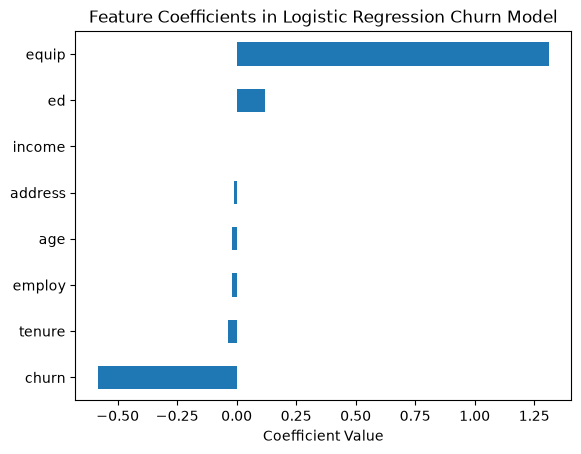

In [85]:
coefficients = pd.Series(LR.coef_[0], index=churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

In [86]:
log_loss(y_test, y_hat_prob)

0.590275774736547